# PRAGMA Phase 3 - Tokenized Parquet shards

Runs the offline tokenized-record writer (`scripts/tokenize_shards.py` / section 10.1) against the processor bundle from `002_fit_processor.ipynb`, then loads the written shards back through `pragma.data.storage` and inspects them: per-split/per-bucket record and token counts, event-length distribution, and manifest checksum verification.

The on-disk format is nested-list Parquet (`ParquetShardStore`), one shard per `(split, event-count bucket)` pair (section 9.3's "bucket by coarse event-count ranges" guidance) — this replaced Phase 2's JSONL placeholder without changing the `TokenizedRecord` contract downstream code depends on.

In [1]:
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from pragma.data.storage import DataManifest, ParquetShardStore, read_dataset

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SHARDS_DIR = REPO_ROOT / "data" / "shards"
SHARDS_DIR

WindowsPath('C:/Users/levyr/Desktop/random-projects/pragma/data/shards')

## Write the shards

Calls the same thin CLI script used in production so this notebook never duplicates its logic (per `CLAUDE.md`'s notebook rule).

In [2]:
result = subprocess.run(
    [sys.executable, str(REPO_ROOT / "scripts" / "tokenize_shards.py")],
    cwd=REPO_ROOT,
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
assert result.returncode == 0

Dropped 15 zero-event records before tokenizing (ADR 0014)
test: 52 records across 3 shards, 65663 value tokens
train: 385 records across 3 shards, 436763 value tokens
val: 48 records across 3 shards, 65781 value tokens
Manifest written to C:\Users\levyr\Desktop\random-projects\pragma\data\shards\manifest.json



## Manifest and shard index

One row per `(split, length_bucket)` shard. `read_dataset` re-verifies every shard's checksum before returning records, so a successful load below is itself proof the manifest matches the data on disk.

In [3]:
manifest = DataManifest.load(SHARDS_DIR)
print(f"schema_version: {manifest.schema_version}")
print(f"processor_train_fingerprint: {manifest.processor_train_fingerprint}")
print(f"total_records: {manifest.total_records}")

shard_index_df = pd.DataFrame([s.__dict__ for s in manifest.shards])
shard_index_df

schema_version: 1
processor_train_fingerprint: 0bd553772ef000bf9ec57ca7add5246d8e73f2da345f079c4dc41f1b66930308
total_records: 485


,path,split,length_bucket,n_records,n_events,n_value_tokens,sha256
0,test_1-49.parquet,test,1-49,5,114,647,543fa84f6baafc3b907e9731fe82991abeb6c52a97678b...
1,test_50-499.parquet,test,50-499,46,9402,49357,ea4c0bc68ddb1c4ab54c6c87d511536e845ec840c200c8...
2,test_500+.parquet,test,500+,1,3000,15659,fc9c663ccd15c6c505212e283ce3de567e7452bdd81053...
3,train_1-49.parquet,train,1-49,57,1114,6443,a69a8e72e38491103eb3425f0a8128e71d93cc46ddb790...
4,train_50-499.parquet,train,50-499,325,72843,383210,5850754955414ddd30b407274e300bfa3d37e4547f4deb...
5,train_500+.parquet,train,500+,3,9000,47110,8fe9737f589341c14a3f275907d161429a531de9854267...
6,val_1-49.parquet,val,1-49,6,41,265,4fbac4b2c8227c00dd06faf3a0c4c793f875c9823cf1e8...
7,val_50-499.parquet,val,50-499,41,9508,49844,ce900a4c05e30ff5c95d95e17f38406db314696f9abce6...
8,val_500+.parquet,val,500+,1,3000,15672,4f3ff207169a873c4088262db87320ade3b7048fa76f18...


## Load every shard back through the storage interface

In [4]:
store = ParquetShardStore()
records = read_dataset(SHARDS_DIR, store)
print(f"loaded {len(records)} tokenized records (checksums verified)")

by_split = {}
for r in records:
    by_split.setdefault(r.split, []).append(r)
{split: len(recs) for split, recs in by_split.items()}

loaded 485 tokenized records (checksums verified)


{'test': 52, 'train': 385, 'val': 48}

In [5]:
n_zero_event = sum(1 for r in records if len(r.events) == 0)
print(f"zero-event records in shards: {n_zero_event}")
assert n_zero_event == 0, "ADR 0014: zero-event customers must never reach a training shard"

zero-event records in shards: 0


## Event-count and token-count summary by split

In [6]:
rows = [
    {
        "split": r.split,
        "entity_id": r.entity_id,
        "n_events": len(r.events),
        "n_events_total": r.n_events_total,
        "events_truncated": r.events_truncated,
        "n_value_tokens": len(r.profile_value_ids())
        + sum(len(e.value_ids()) for e in r.events),
    }
    for r in records
]
record_df = pd.DataFrame(rows)
record_df.groupby("split")[["n_events", "n_value_tokens"]].describe()

n_events                                                            n_value_tokens                                                                 
         count        mean         std  min    25%    50%     75%     max          count         mean          std   min     25%     50%     75%      max
split                                                                                                                                                    
test      52.0  240.692308  404.963350  1.0  113.0  162.5  288.00  3000.0           52.0  1262.750000  2112.357199  17.0  582.75   880.5  1519.5  15659.0
train    385.0  215.472727  274.458937  1.0   90.0  196.0  301.00  3000.0          385.0  1134.449351  1435.842963  11.0  480.00  1037.0  1594.0  15815.0
val       48.0  261.437500  420.947963  1.0  129.0  210.0  279.25  3000.0           48.0  1370.437500  2199.109306  11.0  663.00  1117.0  1448.0  15672.0

## Event-count distribution by split

One sequential hue per split (magnitude), log-scaled x-axis since history lengths span short (single-event) to long-history (thousands of events) entities by construction (section 5.1's edge-case cohorts). Zero-event entities are dropped before tokenizing (ADR 0014), so they never appear here.

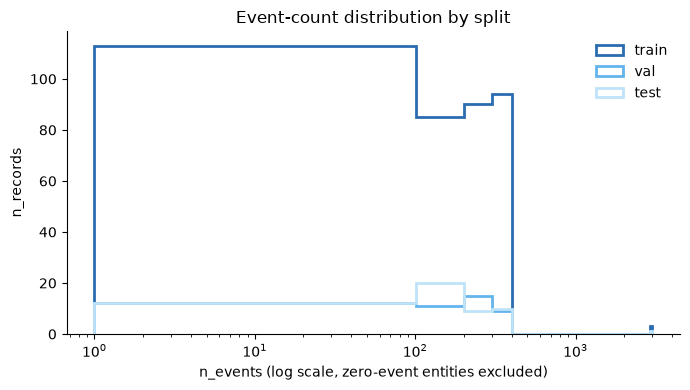

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = {"train": "#2b6cb0", "val": "#63b3ed", "test": "#bee3f8"}
for split in ["train", "val", "test"]:
    values = record_df.loc[record_df["split"] == split, "n_events"]
    values = values[values > 0]
    if len(values):
        ax.hist(
            values,
            bins=30,
            histtype="step",
            linewidth=2,
            color=colors[split],
            label=split,
        )
ax.set_xscale("log")
ax.set_xlabel("n_events (log scale, zero-event entities excluded)")
ax.set_ylabel("n_records")
ax.set_title("Event-count distribution by split")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()

## Spot-check one record end to end

In [8]:
example = by_split["train"][0]
print(f"entity: {example.entity_id}")
print(f"n profile fields: {len(example.profile_fields)}")
print(f"n events: {len(example.events)} (of {example.n_events_total} total)")
print(f"events_truncated: {example.events_truncated}")
if example.events:
    print(f"first event value_ids: {example.events[0].value_ids()}")

entity: u000003
n profile fields: 10
n events: 38 (of 38 total)
events_truncated: False
first event value_ids: [28, 48, 50, 354, 352, 355, 54]
